# 02 — Model 1: Classical ML Baseline (SVM · Random Forest · XGBoost)
**Owner:** Aayush M Pai

**Input:** output of notebook `01_data_preprocessing` (**Add Input → Your Work → Notebooks** → select it).

Hand-crafted features per respiratory cycle (MFCC & Δ-MFCC statistics + spectral/prosodic descriptors, 101 dims) → three classical classifiers.
Hyperparameters are chosen on the **validation patients**; the **test patients** are used once at the end.

**Common evaluation protocol** (identical in every model notebook):
* 3-class (Healthy / Chronic / Non-chronic): accuracy, macro precision/recall/F1, per-class report, confusion matrix
* Screening view (Healthy vs Abnormal): sensitivity, specificity, F1, AUROC
* Cycle-level **and** patient-level (mean probability over a patient's cycles)

In [1]:
import os, glob, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
warnings.filterwarnings("ignore")
SEED = 42; np.random.seed(SEED)

INPUT_DIR = os.environ.get("INPUT_DIR", "/kaggle/input")
WORK_DIR  = os.environ.get("WORK_DIR", "/kaggle/working")
FIG_DIR = os.path.join(WORK_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)

def find(name):
    hits = glob.glob(os.path.join(INPUT_DIR, "**", name), recursive=True) + glob.glob(os.path.join(WORK_DIR, name))
    assert hits, f"{name} not found — add the 01_data_preprocessing notebook output as input"
    return hits[0]

meta = pd.read_csv(find("segments_meta.csv"))
X = np.load(find("handcrafted.npy"))
cfg = json.load(open(find("prep_config.json")))
CLASSES, FEATS = cfg["classes"], cfg["feature_names"]
y = meta["label"].values
tr, va, te = (meta.split == "train").values, (meta.split == "val").values, (meta.split == "test").values
print(X.shape, {s: int(m.sum()) for s, m in zip(["train", "val", "test"], [tr, va, te])})

scaler = StandardScaler().fit(X[tr])
Xs = scaler.transform(X)

(6891, 98) {'train': 4407, 'val': 1650, 'test': 834}


## Common evaluation helper

In [2]:
def evaluate(y_true, prob, patients=None, name="model"):
    """prob: (N, 3) class probabilities. Returns a flat dict of metrics."""
    pred = prob.argmax(1)
    p, r, f, _ = precision_recall_fscore_support(y_true, pred, average="macro", zero_division=0)
    res = dict(model=name, acc=accuracy_score(y_true, pred), macro_precision=p, macro_recall=r, macro_f1=f)
    # screening view: Healthy (0) vs Abnormal (1,2)
    yb, pb = (y_true != 0).astype(int), 1 - prob[:, 0]
    predb = (pred != 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(yb, predb, labels=[0, 1]).ravel()
    res.update(sensitivity=tp / max(tp + fn, 1), specificity=tn / max(tn + fp, 1),
               binary_f1=f1_score(yb, predb, zero_division=0),
               auroc=roc_auc_score(yb, pb) if len(set(yb)) > 1 else float("nan"))
    if patients is not None:   # patient-level: average probabilities over all cycles of a patient
        dfp = pd.DataFrame(prob).assign(patient=patients, y=y_true).groupby("patient").mean()
        pp, yp = dfp[[0, 1, 2]].values, dfp["y"].values.astype(int)
        res.update(patient_acc=accuracy_score(yp, pp.argmax(1)),
                   patient_macro_f1=f1_score(yp, pp.argmax(1), average="macro", zero_division=0))
    return {k: (round(float(v), 4) if not isinstance(v, str) else v) for k, v in res.items()}

def plot_cm(y_true, pred, title, fname):
    cm = confusion_matrix(y_true, pred, labels=range(len(CLASSES)), normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Blues", values_format=".2f")
    plt.title(title); plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, fname), dpi=130); plt.show()

## Hyperparameter selection on validation patients (metric: macro-F1)

In [3]:
sw = compute_sample_weight("balanced", y[tr])
candidates = {
    "SVM (RBF)": [dict(C=C, gamma=g) for C in (0.3, 1, 3, 10) for g in ("scale", 0.01)],
    "Random Forest": [dict(n_estimators=400, max_depth=d, min_samples_leaf=l) for d in (None, 12) for l in (1, 4)],
    "XGBoost": [dict(n_estimators=400, max_depth=d, learning_rate=lr) for d in (3, 6) for lr in (0.05, 0.1)],
}

def build(name, hp):
    if name.startswith("SVM"):
        return SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED, **hp)
    if name == "Random Forest":
        return RandomForestClassifier(class_weight="balanced_subsample", n_jobs=-1, random_state=SEED, **hp)
    return XGBClassifier(objective="multi:softprob", subsample=0.8, colsample_bytree=0.8,
                         eval_metric="mlogloss", n_jobs=-1, random_state=SEED, **hp)

best, tuning_log = {}, []
for name, grid in candidates.items():
    for hp in grid:
        t0 = time.time()
        m = build(name, hp)
        m.fit(Xs[tr], y[tr], **({"sample_weight": sw} if name == "XGBoost" else {}))
        f = f1_score(y[va], m.predict(Xs[va]), average="macro")
        tuning_log.append(dict(model=name, **{k: str(v) for k, v in hp.items()}, val_macro_f1=round(f, 4), sec=round(time.time() - t0, 1)))
        if f > best.get(name, (None, -1))[1]:
            best[name] = (hp, f)
    print(f"{name:14s} best val macro-F1 = {best[name][1]:.4f}  with {best[name][0]}")
pd.DataFrame(tuning_log).to_csv(os.path.join(WORK_DIR, "classical_tuning_log.csv"), index=False)

SVM (RBF)      best val macro-F1 = 0.6745  with {'C': 3, 'gamma': 0.01}
Random Forest  best val macro-F1 = 0.7618  with {'n_estimators': 400, 'max_depth': 12, 'min_samples_leaf': 1}
XGBoost        best val macro-F1 = 0.7290  with {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05}


## Final fit on train+val, single evaluation on test patients

In [4]:
trva = tr | va
sw2 = compute_sample_weight("balanced", y[trva])
results, models, probs = [], {}, {}
for name, (hp, _) in best.items():
    m = build(name, hp)
    m.fit(Xs[trva], y[trva], **({"sample_weight": sw2} if name == "XGBoost" else {}))
    prob = m.predict_proba(Xs[te])
    models[name], probs[name] = m, prob
    results.append(evaluate(y[te], prob, meta.patient.values[te], name))
res_df = pd.DataFrame(results).set_index("model")
res_df

,acc,macro_precision,macro_recall,macro_f1,sensitivity,specificity,binary_f1,auroc,patient_acc,patient_macro_f1
model,,,,,,,,,,
SVM (RBF),0.8945,0.7727,0.7083,0.6787,0.9932,0.2727,0.9499,0.9172,0.6667,0.6556
Random Forest,0.8645,0.8022,0.5465,0.5738,0.9973,0.1010,0.9416,0.8760,0.4444,0.4485
XGBoost,0.8945,0.7794,0.6824,0.6544,0.9946,0.1818,0.9451,0.9166,0.5556,0.5242


===== SVM (RBF) =====
              precision    recall  f1-score   support

     Healthy       0.84      0.27      0.41        99
     Chronic       0.94      0.99      0.96       683
 Non-chronic       0.54      0.87      0.66        52

    accuracy                           0.89       834
   macro avg       0.77      0.71      0.68       834
weighted avg       0.90      0.89      0.88       834



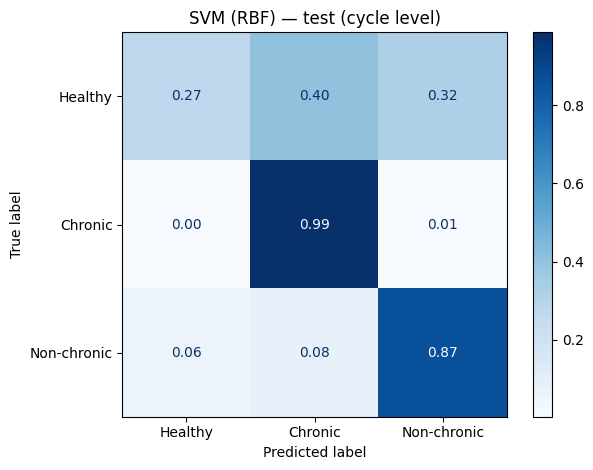

===== Random Forest =====
              precision    recall  f1-score   support

     Healthy       0.83      0.10      0.18        99
     Chronic       0.87      1.00      0.93       683
 Non-chronic       0.70      0.54      0.61        52

    accuracy                           0.86       834
   macro avg       0.80      0.55      0.57       834
weighted avg       0.86      0.86      0.82       834



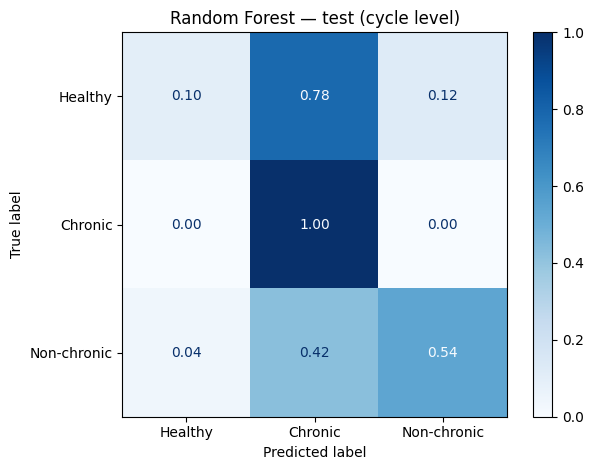

===== XGBoost =====
              precision    recall  f1-score   support

     Healthy       0.82      0.18      0.30        99
     Chronic       0.93      1.00      0.96       683
 Non-chronic       0.59      0.87      0.70        52

    accuracy                           0.89       834
   macro avg       0.78      0.68      0.65       834
weighted avg       0.89      0.89      0.87       834



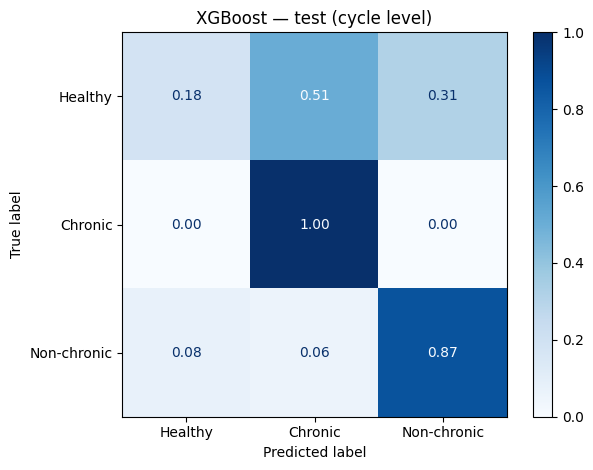

In [5]:
for name, prob in probs.items():
    print(f"===== {name} =====")
    print(classification_report(y[te], prob.argmax(1), labels=range(3), target_names=CLASSES, zero_division=0))
    plot_cm(y[te], prob.argmax(1), f"{name} — test (cycle level)", f"cm_{name.split()[0].lower()}.png")

## Feature importance (which acoustic cues drive the decision?)

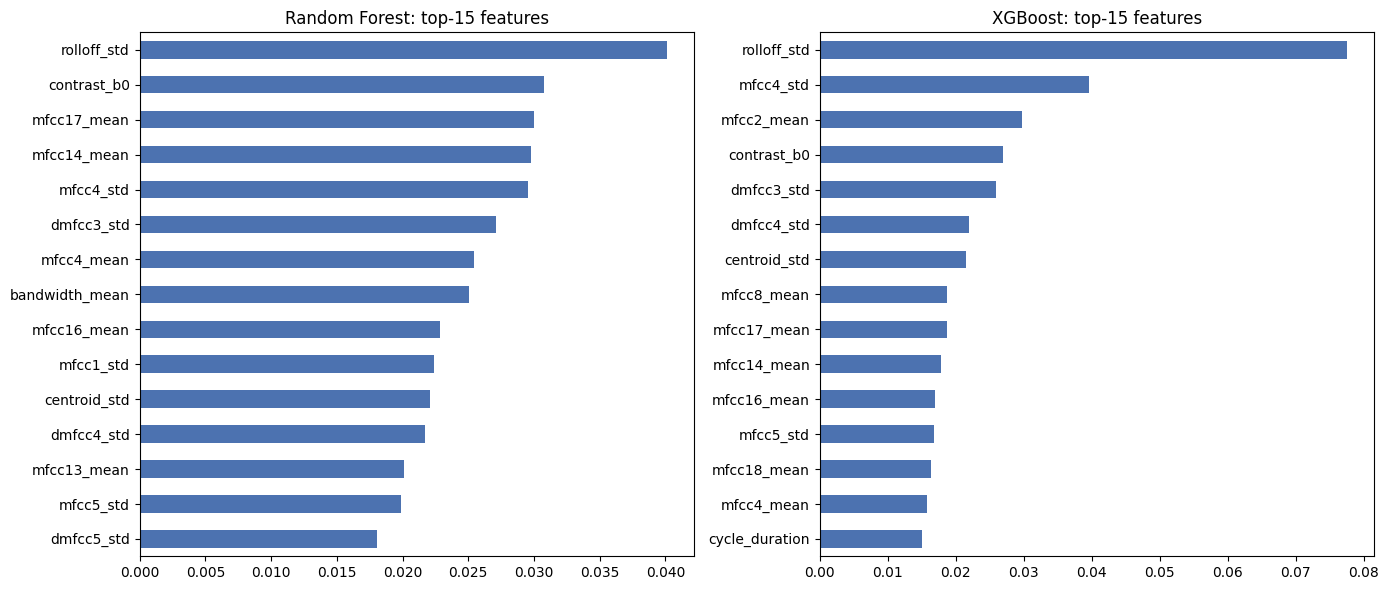

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for k, name in enumerate(["Random Forest", "XGBoost"]):
    imp = pd.Series(models[name].feature_importances_, index=FEATS).sort_values().tail(15)
    imp.plot.barh(ax=ax[k], color="#4C72B0"); ax[k].set_title(f"{name}: top-15 features")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "feature_importance.png"), dpi=130); plt.show()

## Error analysis: where do mistakes happen?
Recall per class split by recording device and by adventitious-sound type — reveals device bias and whether *normal-sounding* cycles of sick patients are the main error source.

In [7]:
best_name = res_df["macro_f1"].idxmax()
ev = meta[te].assign(pred=probs[best_name].argmax(1))
ev["correct"] = ev.pred == ev.label
print(f"Best classical model: {best_name}")
print("\nAccuracy by recording device:\n", ev.groupby("device").correct.agg(["mean", "size"]).round(3))
print("\nAccuracy by cycle annotation:\n", ev.groupby("cycle_label").correct.agg(["mean", "size"]).round(3))
print("\nAccuracy by diagnosis:\n", ev.groupby("diagnosis").correct.agg(["mean", "size"]).round(3))

Best classical model: SVM (RBF)

Accuracy by recording device:
            mean  size
device               
AKGC417L  0.985   611
Litt3200  1.000    61
LittC2SE  1.000    11
Meditron  0.477   151

Accuracy by cycle annotation:
               mean  size
cycle_label             
both         1.000    66
crackle      1.000   203
normal       0.816   474
wheeze       0.989    91

Accuracy by diagnosis:
             mean  size
diagnosis             
COPD       0.987   683
Healthy    0.273    99
LRTI       0.833    24
URTI       0.893    28


In [8]:
res_df.to_csv(os.path.join(WORK_DIR, "results_model1_classical.csv"))
json.dump({k: {"hp": {a: str(b) for a, b in v[0].items()}, "val_macro_f1": round(v[1], 4)} for k, v in best.items()},
          open(os.path.join(WORK_DIR, "classical_best_params.json"), "w"), indent=1)
print(res_df.to_string())

                  acc  macro_precision  macro_recall  macro_f1  sensitivity  specificity  binary_f1   auroc  patient_acc  patient_macro_f1
model                                                                                                                                     
SVM (RBF)      0.8945           0.7727        0.7083    0.6787       0.9932       0.2727     0.9499  0.9172       0.6667            0.6556
Random Forest  0.8645           0.8022        0.5465    0.5738       0.9973       0.1010     0.9416  0.8760       0.4444            0.4485
XGBoost        0.8945           0.7794        0.6824    0.6544       0.9946       0.1818     0.9451  0.9166       0.5556            0.5242
